<a href="https://colab.research.google.com/github/Yelmi95/IA_SIS420/blob/main/Lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Regresión Lineal Multivariable
NOMBRE:Yulitza Alcibia Miranda

GRUPO:2

**Dataset:** Course Completion Prediction  
**Descripción del Dataset**
El dataset contiene información sobre 100,000 estudiantes de cursos en línea, con 40 columnas que incluyen características demográficas, de comportamiento y métricas de rendimiento.

**Variable objetivo**
Se predice Progress_Percentage — porcentaje de progreso del estudiante en el curso.

**Modelos implementados**
Regresión Lineal Multivariable con Gradiente Descendente
Regresión Polinómica de grado 2
Ecuación Normal (solución analítica directa)

In [ ]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot

# Librería para manejo de datos tabulares
import pandas as pd

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Cargar datos desde Google Drive

In [ ]:

df = pd.read_csv('/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/Course_Completion_Prediction.csv')

m = len(df)
print('Numero de ejemplos (m):', m)
print('Numero de columnas originales:', len(df.columns))
print()

# Imprimir algunos puntos de datos
print('{:>25s}{:>25s}{:>20s}'.format('Assignments_Submitted', 'Video_Completion_Rate', 'Progress_%'))
print('-'*70)
for i in range(10):
    print('{:25.0f}{:25.1f}{:20.1f}'.format(
        df['Assignments_Submitted'].iloc[i],
        df['Video_Completion_Rate'].iloc[i],
        df['Progress_Percentage'].iloc[i]
    ))

Numero de ejemplos (m): 100000
Numero de columnas originales: 40

    Assignments_Submitted    Video_Completion_Rate          Progress_%
----------------------------------------------------------------------
                        8                     55.0                70.8
                        4                     84.1                55.6
                        8                     75.6                78.8
                        0                     63.3                24.7
                        5                     86.4                64.9
                        7                     85.9                75.3
                        3                     94.5                55.1
                        7                     79.2                73.4
                       10                     82.3                92.3
                        3                     63.4                42.9



**Normalización de Características**

Al visualizar los datos se puede observar que las características tienen diferentes magnitudes, por lo cual se debe transformar cada valor en una escala de valores similares, con el fin de que el descenso por el gradiente pueda converger más rápidamente.

Antes de normalizar se realiza:

1.Eliminación de columnas no informativas (ID, nombre, fecha)

2.Codificación de variables categóricas con One-Hot Encoding

3.Normalización con media y desviación estándar


In [ ]:
# Paso 1: Eliminar columnas inutiles
df = df.drop(columns=['Student_ID', 'Name', 'Enrollment_Date',
                       'Course_ID', 'Course_Name', 'City', 'Completed'])
print('Despues de drop:', len(df.columns), 'columnas')

# Paso 2: Convertir texto a numeros
cat_cols = ['Gender', 'Education_Level', 'Employment_Status', 'Device_Type',
            'Internet_Connection_Quality', 'Course_Level', 'Category',
            'Payment_Mode', 'Fee_Paid', 'Discount_Used']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print('Despues de encoding:', len(df.columns), 'columnas')

# Paso 3: Separar X e y
y = df['Progress_Percentage'].values
X = df.drop(columns=['Progress_Percentage']).values
m = y.size

print()
print('m =', m)
print('X primeras 3 filas:')
print(X[:3])

Despues de drop: 33 columnas
Despues de encoding: 49 columnas

m = 100000
X primeras 3 filas:
[[1.900e+01 6.000e+01 4.700e+00 3.000e+00 3.000e+01 5.500e+01 2.000e+00
  5.000e-01 1.000e+00 6.000e+00 4.300e+00 8.000e+00 1.000e+00 5.000e+00
  8.090e+01 7.120e+01 0.000e+00 1.740e+03 4.900e+01 3.000e+00 4.000e+00
  3.500e+00 1.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00
  0.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.700e+01 9.000e+01 4.600e+00 4.000e+00 3.700e+01 8.410e+01 2.000e+00
  9.000e-01 3.000e+00 5.000e+00 7.800e+00 4.000e+00 6.000e+00 3.000e+00
  7.840e+01 4.250e+01 2.000e+00 6.147e+03 8.600e+01 0.000e+00 0.000e+00
  4.500e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00

**Aplicar la normalización**

In [ ]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada (primeras 5):', mu[:5])
print('Desviacion estandar (primeras 5):', sigma[:5])
print()
print(X_norm[:3])


Media calculada (primeras 5): [25.70959  51.8173    4.444478  4.78538  33.87818 ]
Desviacion estandar (primeras 5): [ 5.6152642  20.32469977  0.20262998  1.84827981 10.34191278]

[[-1.19488412  0.40259881  1.26102763 -0.96596846 -0.37499639 -0.36683554
  -0.20692399 -0.89221995 -0.74317546  0.31975785 -1.00857969  1.9371073
  -2.43587621  0.60737675  0.60736361  0.19660881 -1.47016487 -0.72607976
  -0.98543505  0.42114253  3.28829207 -0.90189184  1.04461427 -0.14263833
   2.99467896 -0.3353113  -0.52890255 -0.1772483  -0.23102919  1.10712869
  -0.227307   -1.22528086 -0.22847237 -0.42029816  1.00030005 -1.01227534
   1.27214362 -0.30451434 -0.38117149 -0.3337961   0.88331556 -0.41744487
  -0.4970451  -0.33492366  2.99351825 -0.65613477 -1.53299829 -0.49909358]
 [-1.55105614  1.87863538  0.76751724 -0.42492484  0.30186099  1.12104449
  -0.20692399 -0.78643248 -0.45672508 -0.09665316  0.76129396 -0.4658268
   0.51781089 -0.3821021   0.40819663 -1.67774311 -0.20492463  1.38821664
   0.947

Anadir el termino de interseccion a X (columna de unos para X0)

In [ ]:
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(X[:3])


[[ 1.         -1.19488412  0.40259881  1.26102763 -0.96596846 -0.37499639
  -0.36683554 -0.20692399 -0.89221995 -0.74317546  0.31975785 -1.00857969
   1.9371073  -2.43587621  0.60737675  0.60736361  0.19660881 -1.47016487
  -0.72607976 -0.98543505  0.42114253  3.28829207 -0.90189184  1.04461427
  -0.14263833  2.99467896 -0.3353113  -0.52890255 -0.1772483  -0.23102919
   1.10712869 -0.227307   -1.22528086 -0.22847237 -0.42029816  1.00030005
  -1.01227534  1.27214362 -0.30451434 -0.38117149 -0.3337961   0.88331556
  -0.41744487 -0.4970451  -0.33492366  2.99351825 -0.65613477 -1.53299829
  -0.49909358]
 [ 1.         -1.55105614  1.87863538  0.76751724 -0.42492484  0.30186099
   1.12104449 -0.20692399 -0.78643248 -0.45672508 -0.09665316  0.76129396
  -0.4658268   0.51781089 -0.3821021   0.40819663 -1.67774311 -0.20492463
   1.38821664  0.94786527 -1.47205832 -0.91531426  0.52486325 -0.95729115
  -0.14263833 -0.33392561 -0.3353113  -0.52890255 -0.1772483  -0.23102919
   1.10712869 -0.227307

## 3. Regresión Lineal Múltiple con Descenso por el Gradiente

En este modelo se implementa el descenso por el gradiente para un problema de regresión multivariable.

La función de costo en forma vectorizada es:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

La regla de actualización del gradiente es:

$$ \theta := \theta - \frac{\alpha}{m} X^T(X\theta - \vec{y}) $$



In [ ]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    J = 0

    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]  # numero de ejemplos de entrenamiento

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

### Seleccionando coeficientes de aprendizaje

Se selecciona el valor de alpha que produce la convergencia más rápida y estable. Un alpha demasiado grande puede causar divergencia, mientras que uno muy pequeño produce una convergencia lenta.

theta calculado por el descenso por el gradiente: [ 5.38207804e+01  1.89333293e-03  4.39975122e-03  1.91639331e-03
 -6.87217834e-04  2.71666833e-03  6.84702313e+00  2.19339920e-03
  8.32558986e-04  1.72256260e-04  4.34052343e-03  4.65837099e-03
  5.72956491e+00 -4.25465595e+00  1.69721235e-03  3.88508563e-03
  7.66732095e-01  3.28811732e-03 -1.03461394e-02 -8.63050440e-04
  6.59323604e-03  9.87714493e-04  5.41558482e-03 -3.80560631e-03
 -1.74764811e-03 -1.94117201e-03  1.91284362e-03 -2.41752113e-03
 -5.11400595e-05 -1.94239781e-04  9.71350575e-04  3.23317950e-03
 -8.98542531e-04  8.15658582e-04 -6.53341890e-04  3.41746885e-03
  1.24935744e-03 -5.19367595e-04  1.41363368e-03 -1.57850757e-03
 -1.84748815e-04  4.81131704e-03  2.03046344e-03 -5.86284404e-03
 -1.28438877e-03  8.22967095e-04 -8.53375678e-04  4.56614629e-03
  1.97730416e-03]


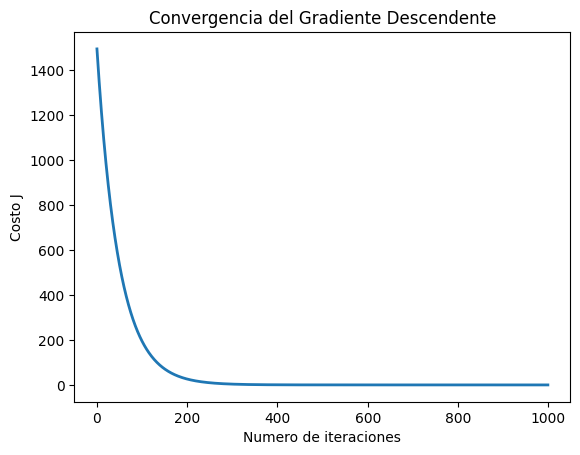

In [ ]:
alpha = 0.01
num_iters = 1000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Gradiente Descendente')

# Muestra los resultados
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

100 predicciones


In [ ]:
# Predicciones sobre los primeros 100 ejemplos
y_pred = np.dot(X, theta)

# Mostrar 100 predicciones (igual que el profesor)
print('=== 100 PREDICCIONES vs VALORES REALES ===')
print('{:>6s}{:>20s}{:>20s}{:>18s}'.format(
    'Ej.', 'Valor Real (%)', 'Prediccion (%)', 'Error Abs.'))
print('-' * 65)
for i in range(100):
    print('{:6d}{:20.2f}{:20.2f}{:18.2f}'.format(
        i+1, y[i], y_pred[i], abs(y[i] - y_pred[i])
    ))

=== 100 PREDICCIONES vs VALORES REALES ===
   Ej.      Valor Real (%)      Prediccion (%)        Error Abs.
-----------------------------------------------------------------
     1               70.80               72.92              2.12
     2               55.60               55.34              0.26
     3               78.80               78.46              0.34
     4               24.70               24.68              0.02
     5               64.90               64.66              0.24
     6               75.30               75.03              0.27
     7               55.10               54.92              0.18
     8               73.40               72.98              0.42
     9               92.30               91.80              0.50
    10               42.90               42.70              0.20
    11               52.00               51.82              0.18
    12               55.20               54.97              0.23
    13               40.60               42.89

## Ecuacion de la Normal

Una manera de calcular rápidamente el modelo de una regresión lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y} $$

Utilizar esta formula **no requiere que se escale ninguna caracteristica**, y se obtendra una solucion exacta con un solo calculo: no hay bucles de convergencia como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas.

In [ ]:
X_normal = np.concatenate([
    np.ones((m, 1)),
    df.drop(columns=['Progress_Percentage']).values
], axis=1)

print(X_normal.shape)

(100000, 49)


In [ ]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

    return theta

In [ ]:
# Calcula los parametros con la ecuacion de la normal
theta_normal = normalEqn(X_normal, y)

print('Theta calculado a partir de la ecuacion de la normal:')
print(theta_normal)

Theta calculado a partir de la ecuacion de la normal:
[-2.80387380e-04 -5.07725520e-05 -3.04512168e-05  1.35757044e-06
 -8.13446628e-05  9.76981878e-06  3.49997365e-01  1.02790421e-04
  2.37411899e-05  2.85253323e-05 -3.20714220e-05  1.71466014e-05
  6.00021879e+00  2.92465828e-04  7.37521881e-05  2.09830133e-06
  5.00028607e-02  1.19226519e-06 -2.83245170e-08 -5.90308104e-06
 -3.27226951e-05  1.15031116e-04  2.42000541e-04  1.47573507e-04
  6.31451692e-04 -3.05553266e-04 -3.47264424e-04 -2.58327426e-04
 -7.25014203e-04 -4.27100944e-04 -6.40735189e-05  9.01832306e-04
 -7.27071095e-06 -8.42772640e-04  4.68493386e-05  3.07296416e-04
 -1.42330096e-03 -6.99354740e-04  2.66080750e-04 -2.50746235e-04
 -2.27165883e-04  4.07689190e-04 -5.77603618e-04 -9.52777376e-05
 -5.26690078e-04 -3.37506851e-04  6.12411984e-05  1.52397221e-04
 -9.38495585e-05]


 100 predicciones con Ecuación Normal

In [ ]:
y_pred_normal = np.dot(X_normal, theta_normal)

print('=== 100 PREDICCIONES vs VALORES REALES (Ecuacion Normal) ===')
print('{:>6s}{:>20s}{:>20s}{:>18s}'.format(
    'Ej.', 'Valor Real (%)', 'Prediccion (%)', 'Error Abs.'))
print('-' * 65)
for i in range(100):
    print('{:6d}{:20.2f}{:20.2f}{:18.2f}'.format(
        i+1, y[i], y_pred_normal[i], abs(y[i] - y_pred_normal[i])
    ))

=== 100 PREDICCIONES vs VALORES REALES (Ecuacion Normal) ===
   Ej.      Valor Real (%)      Prediccion (%)        Error Abs.
-----------------------------------------------------------------
     1               70.80               70.81              0.01
     2               55.60               55.56              0.04
     3               78.80               78.85              0.05
     4               24.70               24.73              0.03
     5               64.90               64.89              0.01
     6               75.30               75.35              0.05
     7               55.10               55.10              0.00
     8               73.40               73.36              0.04
     9               92.30               92.27              0.03
    10               42.90               42.90              0.00
    11               52.00               52.01              0.01
    12               55.20               55.24              0.04
    13               40.60  

## 4. Regresión Polinómica

La regresión polinómica amplía el modelo lineal incorporando términos cuadráticos e interacciones entre las variables, lo que permite capturar relaciones no lineales entre las features y la variable objetivo.

Para un modelo de grado 2, se generan términos del tipo:

$$ h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 + \theta_4 x_1 x_2 + \theta_5 x_2^2 + \cdots $$

Para evitar una explosión de dimensiones con las 48 features disponibles, se seleccionan las **5 variables más correlacionadas** con `Progress_Percentage`:
- `Assignments_Submitted` (r = 0.833)
- `Assignments_Missed` (r = -0.820)
- `Video_Completion_Rate` (r = 0.591)
- `Project_Grade` (r = 0.166)
- `Quiz_Score_Avg` (r = 0.125)

In [ ]:
# Seleccionar las 5 features mas correlacionadas
top5_idx = [
    list(df.drop(columns=['Progress_Percentage']).columns).index('Assignments_Submitted'),
    list(df.drop(columns=['Progress_Percentage']).columns).index('Assignments_Missed'),
    list(df.drop(columns=['Progress_Percentage']).columns).index('Video_Completion_Rate'),
    list(df.drop(columns=['Progress_Percentage']).columns).index('Project_Grade'),
    list(df.drop(columns=['Progress_Percentage']).columns).index('Quiz_Score_Avg')
]

# Tomar solo esas 5 columnas normalizadas
X_top5 = X_norm[:, top5_idx]
print('Shape X_top5:', X_top5.shape)
print(X_top5[:3])

Shape X_top5: (100000, 5)
[[ 1.9371073  -2.43587621 -0.36683554  0.19660881  0.60736361]
 [-0.4658268   0.51781089  1.12104449 -1.67774311  0.40819663]
 [ 1.9371073  -1.84513879  0.68644036  1.28725957  2.12899933]]


In [ ]:
def mapFeaturePoly(X):
    n = X.shape[1]
    out = [X]
    for i in range(n):
        for j in range(i, n):
            out.append((X[:, i] * X[:, j]).reshape(-1, 1))
    return np.concatenate(out, axis=1)

X_poly = mapFeaturePoly(X_top5)

# Anadir columna de unos
X_poly = np.concatenate([np.ones((m, 1)), X_poly], axis=1)

print('Features polinomicas:', X_poly.shape[1] - 1)
print(X_poly[:3])

Features polinomicas: 20
[[ 1.          1.9371073  -2.43587621 -0.36683554  0.19660881  0.60736361
   3.7523847  -4.7185536  -0.71059981  0.38085235  1.17652848  5.93349293
   0.89356598 -0.47891471 -1.47946257  0.13456832 -0.0721231  -0.22280256
   0.03865502  0.11941303  0.36889055]
 [ 1.         -0.4658268   0.51781089  1.12104449 -1.67774311  0.40819663
   0.21699461 -0.24121019 -0.52221256  0.7815377  -0.19014893  0.26812811
   0.58048904 -0.86875365  0.21136866  1.25674075 -1.88082467  0.45760658
   2.81482196 -0.68484908  0.16662449]
 [ 1.          1.9371073  -1.84513879  0.68644036  1.28725957  2.12899933
   3.7523847  -3.57423183  1.32970863  2.49355992  4.12410016  3.40453717
  -1.26657773 -2.37517258 -3.92829926  0.47120036  0.88362692  1.46143106
   1.65703721  2.74057478  4.53263816]]


Entrenar modelo polinómico:

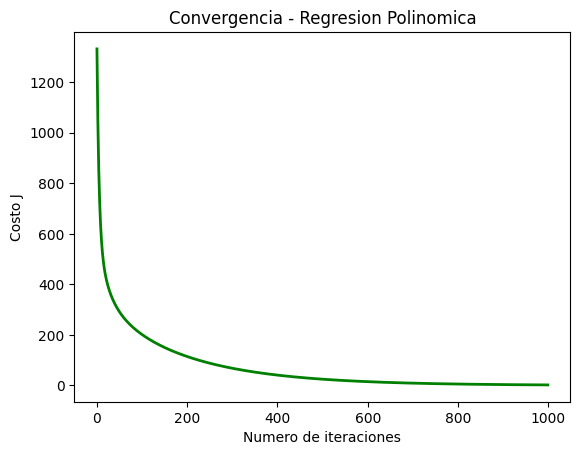

theta calculado por la regresion polinomica: [ 5.01580849e+01  5.77197758e+00 -4.18136612e+00  7.27109781e+00
  8.61408217e-01  8.50978227e-02  6.57124073e-01  1.14095116e-01
 -1.63203911e-02 -6.89482442e-02 -7.29340321e-02  2.68247004e-02
  5.68866867e-02  3.64371913e-02  6.04631828e-02  9.25091304e-01
 -7.99660310e-02 -5.89909118e-02  6.49363052e-01 -1.46266479e-01
  6.41146306e-01]


In [ ]:
alpha_poly     = 0.01
num_iters_poly = 1000

theta_poly = np.zeros(X_poly.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(
    X_poly, y, theta_poly, alpha_poly, num_iters_poly
)

# Grafica de costo
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2, color='green')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia - Regresion Polinomica')
pyplot.show()

print('theta calculado por la regresion polinomica: {:s}'.format(str(theta_poly)))

 100 predicciones con polinomicas

In [ ]:
y_pred_poly = np.dot(X_poly, theta_poly)

print('=== 100 PREDICCIONES vs VALORES REALES (Regresion Polinomica) ===')
print('{:>6s}{:>20s}{:>20s}{:>18s}'.format(
    'Ej.', 'Valor Real (%)', 'Prediccion (%)', 'Error Abs.'))
print('-' * 65)
for i in range(100):
    print('{:6d}{:20.2f}{:20.2f}{:18.2f}'.format(
        i+1, y[i], y_pred_poly[i], abs(y[i] - y_pred_poly[i])
    ))

=== 100 PREDICCIONES vs VALORES REALES (Regresion Polinomica) ===
   Ej.      Valor Real (%)      Prediccion (%)        Error Abs.
-----------------------------------------------------------------
     1               70.80               71.40              0.60
     2               55.60               55.47              0.13
     3               78.80               80.45              1.65
     4               24.70               26.30              1.60
     5               64.90               64.91              0.01
     6               75.30               76.66              1.36
     7               55.10               55.78              0.68
     8               73.40               71.35              2.05
     9               92.30               94.78              2.48
    10               42.90               40.87              2.03
    11               52.00               54.53              2.53
    12               55.20               52.27              2.93
    13               40

## 6. Comparacion de los 3 Modelos

Se comparan los tres modelos implementados utilizando las metricas **MSE**, **RMSE** y **R2**.
- **MSE / RMSE**: error cuadratico medio — valores menores indican mejor ajuste.
- **R2**: coeficiente de determinacion — valores cercanos a 1 indican que el modelo explica bien la variabilidad de los datos.

La **Ecuacion Normal** produce la solucion exacta y sirve como referencia de validacion para los demas modelos. El modelo de **Regresion Lineal Multiple** con gradiente descendente utiliza las 48 features disponibles, mientras que la **Regresion Polinomica** usa las 5 mas correlacionadas con terminos cuadraticos.

In [ ]:
# Metricas Modelo 1 - Gradiente Descendente
y_pred_gd = np.dot(X, theta)
mse_gd    = (1/m) * np.sum((y_pred_gd - y)**2)
rmse_gd   = np.sqrt(mse_gd)
r2_gd     = 1 - (np.sum((y - y_pred_gd)**2) / np.sum((y - np.mean(y))**2))

# Metricas Modelo 2 - Polinomica
mse_poly  = (1/m) * np.sum((y_pred_poly - y)**2)
rmse_poly = np.sqrt(mse_poly)
r2_poly   = 1 - (np.sum((y - y_pred_poly)**2) / np.sum((y - np.mean(y))**2))

# Metricas Modelo 3 - Ecuacion Normal
mse_normal  = (1/m) * np.sum((y_pred_normal - y)**2)
rmse_normal = np.sqrt(mse_normal)
r2_normal   = 1 - (np.sum((y - y_pred_normal)**2) / np.sum((y - np.mean(y))**2))

# Tabla comparativa
print('=' * 65)
print('         COMPARACION FINAL DE LOS 3 MODELOS')
print('=' * 65)
print('{:<35s}{:>8s}{:>9s}{:>9s}'.format('Modelo', 'MSE', 'RMSE', 'R2'))
print('-' * 65)
print('{:<35s}{:>8.4f}{:>9.4f}{:>9.4f}'.format(
    'Reg. Lineal Multiple (Gradiente)', mse_gd, rmse_gd, r2_gd))
print('{:<35s}{:>8.4f}{:>9.4f}{:>9.4f}'.format(
    'Regresion Polinomica (Grado 2)', mse_poly, rmse_poly, r2_poly))
print('{:<35s}{:>8.4f}{:>9.4f}{:>9.4f}'.format(
    'Ecuacion Normal', mse_normal, rmse_normal, r2_normal))
print('=' * 65)

         COMPARACION FINAL DE LOS 3 MODELOS
Modelo                                  MSE     RMSE       R2
-----------------------------------------------------------------
Reg. Lineal Multiple (Gradiente)     0.5800   0.7616   0.9963
Regresion Polinomica (Grado 2)       4.4755   2.1155   0.9713
Ecuacion Normal                      0.0009   0.0307   1.0000


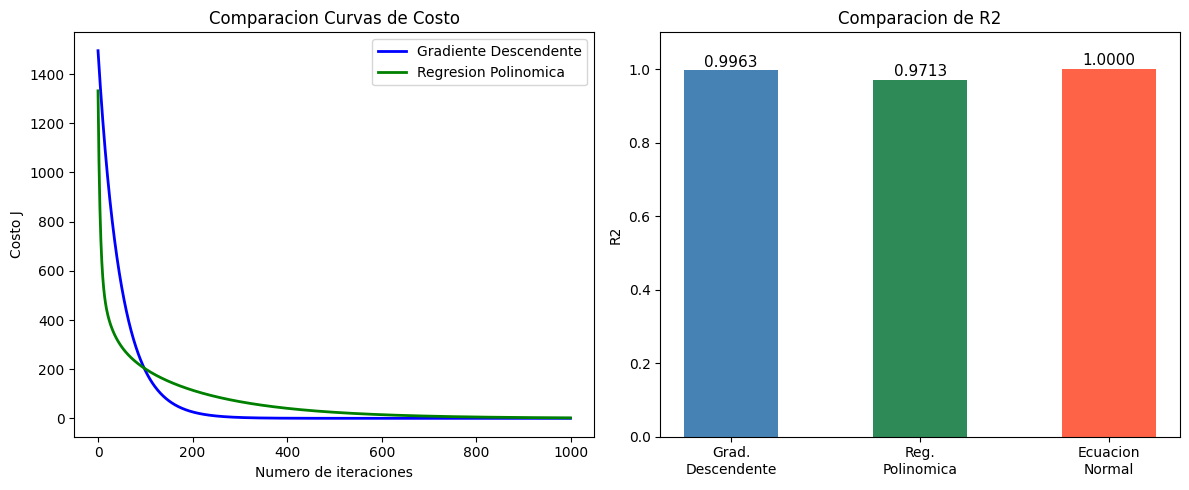

In [ ]:
# Grafico comparativo de curvas de costo
pyplot.figure(figsize=(12, 5))

pyplot.subplot(1, 2, 1)
pyplot.plot(np.arange(len(J_history)),      J_history,      lw=2, color='blue',  label='Gradiente Descendente')
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2, color='green', label='Regresion Polinomica')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Comparacion Curvas de Costo')
pyplot.legend()

pyplot.subplot(1, 2, 2)
modelos = ['Grad.\nDescendente', 'Reg.\nPolinomica', 'Ecuacion\nNormal']
r2_vals = [r2_gd, r2_poly, r2_normal]
colores = ['steelblue', 'seagreen', 'tomato']
bars = pyplot.bar(modelos, r2_vals, color=colores, width=0.5)
pyplot.ylim(0, 1.1)
pyplot.ylabel('R2')
pyplot.title('Comparacion de R2')
for bar, val in zip(bars, r2_vals):
    pyplot.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                '{:.4f}'.format(val), ha='center', fontsize=11)

pyplot.tight_layout()
pyplot.show()